In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 17  # Set global font size for all text elements
matplotlib.rcParams['figure.autolayout'] = True


In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

In [5]:
path_9='/Users/paarthsachan/technical/State_of_health_battery/Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/data/Matlab/RW9.mat'
path_10='/Users/paarthsachan/technical/State_of_health_battery/Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/data/Matlab/RW10.mat'
path_11='/Users/paarthsachan/technical/State_of_health_battery/Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/data/Matlab/RW11.mat'
path_12='/Users/paarthsachan/technical/State_of_health_battery/Battery_Uniform_Distribution_Charge_Discharge_DataSet_2Post/data/Matlab/RW12.mat'

annots = loadmat(path_9)
annots_=annots['data'][0][0]
steps=annots_[0][0]

In [6]:
dict_types=[]
for i in range(len(steps)):
    step=steps[i]
    #print(step[0][0])
    if(step[0][0] not in dict_types):
        dict_types.append(step[0][0])
    #break
  
    

In [7]:
dict_types


['reference charge',
 'reference discharge',
 'pulsed load (rest)',
 'pulsed load (discharge)',
 'rest (random walk)',
 'discharge (random walk)',
 'charge (random walk)',
 'pulsed charge (rest)',
 'pulsed charge (charge)',
 'rest prior low current discharge',
 'low current discharge at 0.04A',
 'rest post low current discharge',
 'rest post reference charge',
 'rest post reference discharge',
 'rest post pulsed load or charge']

low current discharge at 0.04A


100%|██████████| 2/2 [00:00<00:00,  4.70it/s]


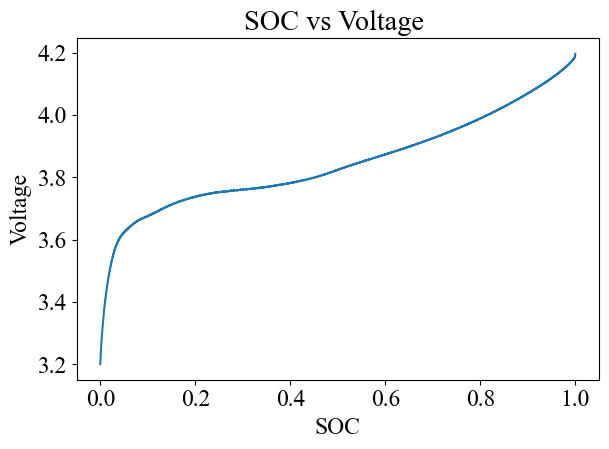

In [8]:
soc_combined=[]
voltage_combined=[]
##Initial Capacity was 2200 Amphere Hour
for type_ in dict_types:
#     print(type_)
#     pass

    if((type_=='low current discharge at 0.04A')):
        print(type_)
        
        train_scores=np.array([])
        test_scores=np.array([])
        all_current=[]
        coverage_scores_arr=np.array([])
        out_bound_scores=np.array([])
        list_=[]
        for i in range(len(steps)):
            if(steps[i][0][0]==type_):
                list_.append(i)
        
        
        for index_current in tqdm(range(len(list_))):
                index_current_=list_[index_current]
                step=steps[index_current_]
                type_=step[0][0]
                time_array=step[3][0]

                non_relative_time=step[2][0]
                voltage_array=step[4][0]+1e-7
                current_array=step[5][0]+1e-7
                temperature_array=step[6][0]
                SOC_array = []
                
                ## Total capacity in amphere seconds
                Total_capacity = np.trapz(current_array, x=time_array)
                
                for i in range(len(time_array)):
                    discharged = np.trapz(current_array[:i+1], 
                                          x=time_array[:i+1])
                    SOC = 1-(discharged/Total_capacity)
                    SOC_array.append(SOC)
                
                soc_combined.append(SOC_array)
                voltage_combined.append(voltage_array)
               

        
    
    else:
        pass

#print(soc_combined[0])
plt.plot(soc_combined[0],voltage_combined[0])
plt.title('SOC vs Voltage ')
plt.xlabel('SOC')
plt.ylabel('Voltage')
#plt.savefig('/kaggle/working/my_plot.pdf')  # Adjust the path as needed

plt.show()  # Display the plot as output



    


        
    


In [9]:
train_soc=soc_combined[0]
train_voltage=voltage_combined[0]

test_soc=soc_combined[1]
test_voltage=voltage_combined[1]

In [10]:
train_soc_tensor = torch.Tensor(train_soc)
train_voltage_tensor = torch.Tensor(train_voltage)
test_soc_tensor = torch.Tensor(test_soc)
test_voltage_tensor = torch.Tensor(test_voltage)

# Combine SOC and voltage tensors into a single dataset
train_dataset = TensorDataset(train_voltage_tensor,train_soc_tensor)
test_dataset = TensorDataset(test_voltage_tensor, test_soc_tensor)

# Define batch size for your data loader
batch_size = 32  # You can adjust this to your preference

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [11]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        
        self.input_layer = nn.Linear(1, 10)  # One input feature, 10 hidden units
        self.hidden_layer = nn.Linear(10, 1) # 10 hidden units, one output

    def forward(self, x):
        x = torch.relu(self.input_layer(x))
        x = torch.sigmoid(self.hidden_layer(x))
        return x

# Instantiate the model
model = MyModel()


In [12]:
num_epochs=1000

In [13]:
model = MyModel()

# Define loss function and optimizer
criterion = nn.MSELoss()  # You can use Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=4e-3)
num_epochs=1000
training_losses = []
for epoch in range(num_epochs):
    epoch_losses = []
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        #print(inputs)
        inputs = torch.unsqueeze(inputs,-1)
        targets = torch.unsqueeze(targets,-1)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    
    # Calculate and store the average loss for the epoch
    avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)
    training_losses.append(avg_epoch_loss)

# Evaluate the model
model.eval()
test_losses = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = torch.unsqueeze(inputs,-1)
        targets = torch.unsqueeze(targets,-1)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

# Print the final training and testing losses
print("Final Training Loss:", training_losses[-1])
print("Final Testing Loss:", sum(test_losses) / len(test_losses))


Final Training Loss: 6.0342103017267906e-05
Final Testing Loss: 0.00014091259314497005


In [14]:
torch.save(model.state_dict(), 'soc_model.pth')



In [16]:
for inputs, targets in train_loader:
    inputs = torch.unsqueeze(inputs,-1)
    targets = torch.unsqueeze(targets,-1)
    print(inputs.shape,targets.shape)

torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
torch.Size([32, 1]) torch.Size([32, 1])
